# **Mini Project 2**

0. Requirements:
   
   If you do not have the following packages installed, run the command below to install them.

In [3]:
#!pip install numpy
#!pip install nltk
#!pip install shap
#!pip install matplotlib
#!pip install tensorflow
#!pip install scikit-learn
#!pip install lime
#!pip install codecarbon

In [20]:
import os
import re
import numpy as np
import string
import seaborn as sns
import nltk
import time
import shap
import matplotlib.pyplot as plt
import tensorflow as tf
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from lime.lime_text import LimeTextExplainer
from sklearn.utils.class_weight import compute_class_weight
from codecarbon import EmissionsTracker
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

[codecarbon INFO @ 21:57:25] Energy consumed for RAM : 0.007621 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:57:25] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:57:25] Energy consumed for All CPU : 0.032415 kWh
[codecarbon INFO @ 21:57:25] 0.040036 kWh of electricity and 0.000000 L of water were used since the beginning.


1. Data Preparation
   
    •	Goal: Load and inspect the IMDb dataset of labeled movie reviews.

    •	Task: Download the dataset (https://ai.stanford.edu/~amaas/data/sentiment/), and prepare labels (positive = 1, negative = 0) for training and test sets.

2. Text Preprocessing

    •	Goal: Clean and normalize raw text reviews.

    •	Task: Convert text to lowercase, remove HTML tags and punctuation, remove stopwords, and pad sequences to a fixed length (e.g., 200).


In [5]:

nltk.download('stopwords')

# Create a set of English stopwords for filtering

stop_words = set(stopwords.words('english'))

# Function to clean a single text string

def clean_text(text):
    text = text.lower()                              
    text = re.sub(r'<.*?>', '', text)               
    text = text.translate(str.maketrans('', '', string.punctuation))  
    words = text.split()
    words = [word for word in words if word not in stop_words]       
    return ' '.join(words)

# Function to load and clean reviews from a given directory

def load_reviews_from_dir(directory, label):
    reviews = []
    labels = []

    for filename in os.listdir(directory):
        if filename.endswith(".txt"):
            filepath = os.path.join(directory, filename)
            with open(filepath, 'r', encoding='utf-8') as file:
                text = file.read()
                cleaned_text = clean_text(text)
                reviews.append(cleaned_text)
                labels.append(label)

    return reviews, labels


# Load and preprocess training and testing data

train_path = r"C:\Users\André Kevin Omouala\Downloads\Bases de données I\aclImdb_v1\aclImdb\train"
test_path = r"C:\Users\André Kevin Omouala\Downloads\Bases de données I\aclImdb_v1\aclImdb\test"

train_pos_reviews, train_pos_labels = load_reviews_from_dir(os.path.join(train_path, "pos"), 1)
train_neg_reviews, train_neg_labels = load_reviews_from_dir(os.path.join(train_path, "neg"), 0)

test_pos_reviews, test_pos_labels = load_reviews_from_dir(os.path.join(test_path, "pos"), 1)
test_neg_reviews, test_neg_labels = load_reviews_from_dir(os.path.join(test_path, "neg"), 0)

X_train = train_pos_reviews + train_neg_reviews
y_train = train_pos_labels + train_neg_labels

X_test = test_pos_reviews + test_neg_reviews
y_test = test_pos_labels + test_neg_labels

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("First cleaned review:", X_train[0][:300])
print("First label:", y_train[0])


[nltk_data] Downloading package stopwords to C:\Users\André Kevin
[nltk_data]     Omouala\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Training samples: 25000
Testing samples: 25000
First cleaned review: bromwell high cartoon comedy ran time programs school life teachers 35 years teaching profession lead believe bromwell highs satire much closer reality teachers scramble survive financially insightful students see right pathetic teachers pomp pettiness whole situation remind schools knew students sa
First label: 1


3. Tokenization and Sequence Vectorization
   
    •	Goal: Convert preprocessed text into numerical format.
   
    •	Task: Use Keras Tokenizer to generate a word index and convert reviews into padded integer sequences.


In [35]:
# Create a tokenizer that will keep the top 12,000 most frequent words

max_words = 12000
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Convert training and test texts into sequences of integers

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad or truncate the sequences so that all inputs have the same length (200 words)

max_len = 200
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

# Convert labels to numpy arrays for training

y_train = np.array(y_train)
y_test = np.array(y_test)

print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("First 10 words in word index:", list(tokenizer.word_index.items())[:10])

[codecarbon INFO @ 06:48:51] Energy consumed for RAM : 0.096137 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 06:48:52] Delta energy consumed for CPU with constant : 0.000178 kWh, power : 42.5 W
[codecarbon INFO @ 06:48:52] Energy consumed for All CPU : 0.408731 kWh
[codecarbon INFO @ 06:48:52] 0.504869 kWh of electricity and 0.000000 L of water were used since the beginning.


X_train_pad shape: (25000, 200)
X_test_pad shape: (25000, 200)
y_train shape: (25000,)
y_test shape: (25000,)
First 10 words in word index: [('<OOV>', 1), ('movie', 2), ('film', 3), ('one', 4), ('like', 5), ('good', 6), ('even', 7), ('would', 8), ('time', 9), ('really', 10)]


[codecarbon INFO @ 06:49:06] Energy consumed for RAM : 0.096178 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 06:49:06] Delta energy consumed for CPU with constant : 0.000174 kWh, power : 42.5 W
[codecarbon INFO @ 06:49:06] Energy consumed for All CPU : 0.408906 kWh
[codecarbon INFO @ 06:49:06] 0.505084 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 06:49:21] Energy consumed for RAM : 0.096220 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 06:49:21] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 06:49:22] Energy consumed for All CPU : 0.409083 kWh
[codecarbon INFO @ 06:49:22] 0.505303 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 06:49:37] Energy consumed for RAM : 0.096262 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 06:49:37] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 06:49:37] Energy consumed for All CPU

4. Model Design and Training

    •	Goal: Train a deep neural network using Bidirectional LSTM layers.
   
    •	Task:
   
        o	Use two stacked Bidirectional LSTM layers followed by Dense and Dropout.
   
        o	Use EarlyStopping to prevent overfitting.

In [37]:
# Define a sequential model for binary sentiment classification

model = Sequential([
    Input(shape=(200,)),
    Embedding(input_dim=12000, output_dim=128),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile the model with Adam optimizer and binary cross-entropy loss

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 200, 128)       │     1,536,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ (None, 200, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,680,257 (6.41 MB)

 Trainable params: 1,680,257 (6.41 MB)

 Non-trainable params: 0 (0.00 B)

[codecarbon INFO @ 07:15:22] Energy consumed for RAM : 0.100552 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 07:15:22] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 07:15:22] Energy consumed for All CPU : 0.427504 kWh
[codecarbon INFO @ 07:15:22] 0.528057 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 07:15:37] Energy consumed for RAM : 0.100594 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 07:15:38] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 07:15:38] Energy consumed for All CPU : 0.427682 kWh
[codecarbon INFO @ 07:15:38] 0.528276 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 07:15:52] Energy consumed for RAM : 0.100636 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 07:15:53] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 07:15:53] Energy consumed for All CPU

In [14]:
# Split the training data into training and validation sets (80/20 split)

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_pad,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Set up early stopping to prevent overfitting (stop if no improvement for 4 epochs)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

# Initialize the CodeCarbon tracker to measure the carbon emissions during training

tracker = EmissionsTracker()
tracker.start()

# Train the model using the training data and validate on the validation set

history = model.fit(
    X_train_final,
    y_train_final,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

# Stop the emissions tracker and capture the total carbon footprint

emissions = tracker.stop()

print("Training set shape:", X_train_final.shape)
print("Validation set shape:", X_val.shape)
print("Carbon emissions (kg CO2eq):", emissions)


[codecarbon WARNING @ 21:22:18] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 21:22:18] [setup] RAM Tracking...
[codecarbon INFO @ 21:22:18] [setup] CPU Tracking...
[codecarbon WARNING @ 21:22:18] We saw that you have a 13th Gen Intel(R) Core(TM) i7-13700H but we don't know it. Please contact us.
[codecarbon WARNING @ 21:22:18] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 21:22:18] CPU Model on constant consumption mode: 13th Gen Intel(R) Core(TM) i7-13700H
[codecarbon WARNING @ 21:22:18] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 21:22:18] [setup] GPU Tracking...
[codecarbon INFO @ 21:22:18] No GPU found.
[codecarbon INFO @ 21:22:18] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: globa

Epoch 1/10


[codecarbon INFO @ 21:22:24] Energy consumed for RAM : 0.001791 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:22:24] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:22:24] Energy consumed for All CPU : 0.007617 kWh
[codecarbon INFO @ 21:22:24] 0.009407 kWh of electricity and 0.000000 L of water were used since the beginning.


 10/313 ━━━━━━━━━━━━━━━━━━━━ 2:41 532ms/step - accuracy: 0.5112 - loss: 0.6925

[codecarbon INFO @ 21:22:37] Energy consumed for RAM : 0.000042 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:22:37] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:22:37] Energy consumed for All CPU : 0.000177 kWh
[codecarbon INFO @ 21:22:37] 0.000219 kWh of electricity and 0.000000 L of water were used since the beginning.


...

[codecarbon INFO @ 21:37:38] Energy consumed for RAM : 0.002540 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:37:38] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:37:38] Energy consumed for All CPU : 0.010805 kWh
[codecarbon INFO @ 21:37:38] 0.013345 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 21:37:39] Energy consumed for RAM : 0.004331 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:37:39] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:37:39] Energy consumed for All CPU : 0.018421 kWh
[codecarbon INFO @ 21:37:39] 0.022752 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 21:37:39] 0.000057 g.CO2eq/s mean an estimation of 1.8091626243508303 kg.CO2eq/year


313/313 ━━━━━━━━━━━━━━━━━━━━ 177s 566ms/step - accuracy: 0.9827 - loss: 0.0558 - val_accuracy: 0.8448 - val_loss: 0.6240


[codecarbon INFO @ 21:37:53] Energy consumed for RAM : 0.002582 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:37:53] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:37:53] Energy consumed for All CPU : 0.010982 kWh
[codecarbon INFO @ 21:37:53] 0.013564 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 21:37:54] Energy consumed for RAM : 0.004372 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:37:54] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:37:54] Energy consumed for All CPU : 0.018598 kWh
[codecarbon INFO @ 21:37:54] 0.022970 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 21:38:08] Energy consumed for RAM : 0.002623 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:38:08] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:38:08] Energy consumed for All CPU

Training set shape: (20000, 200)
Validation set shape: (5000, 200)
Carbon emissions (kg CO2eq): 5.4572979171865136e-05


[codecarbon INFO @ 21:38:24] Energy consumed for RAM : 0.004456 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:38:24] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:38:24] Energy consumed for All CPU : 0.018952 kWh
[codecarbon INFO @ 21:38:24] 0.023408 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 21:38:39] Energy consumed for RAM : 0.004497 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:38:39] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:38:39] Energy consumed for All CPU : 0.019129 kWh
[codecarbon INFO @ 21:38:39] 0.023627 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 21:38:54] Energy consumed for RAM : 0.004539 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:38:54] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:38:54] Energy consumed for All CPU

5. Carbon Footprint Analysis
   
    •	Goal: Track and report energy usage during training.
   
    •	Task: Use CodeCarbon to measure carbon emissions and display results in the notebook. You can find needed information here: https://mlco2.github.io/codecarbon/  &  https://codecarbon.io/


In [16]:
# Display the total carbon emissions generated during model training
print(f"Emissions during model training: {emissions:.10f} kgCO2eq")

Emissions during model training: 0.0000545730 kgCO2eq


[codecarbon INFO @ 21:44:10] Energy consumed for RAM : 0.005414 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:44:10] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:44:10] Energy consumed for All CPU : 0.023026 kWh
[codecarbon INFO @ 21:44:10] 0.028440 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 21:44:25] Energy consumed for RAM : 0.005455 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:44:25] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:44:25] Energy consumed for All CPU : 0.023203 kWh
[codecarbon INFO @ 21:44:25] 0.028659 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 21:44:40] Energy consumed for RAM : 0.005497 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:44:40] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:44:40] Energy consumed for All CPU

6. Model Evaluation
   
    •	Goal: Assess the performance of your trained model.
   
    •	Task: Report training and validation accuracy/loss. Test the model on new review examples and interpret the predictions.


In [17]:
# Evaluate the trained model on the test dataset to check final performance
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test, verbose=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

120/782 ━━━━━━━━━━━━━━━━━━━━ 1:09 105ms/step - accuracy: 0.8328 - loss: 0.4038

[codecarbon INFO @ 21:47:25] Energy consumed for RAM : 0.005955 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:47:25] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:47:25] Energy consumed for All CPU : 0.025329 kWh
[codecarbon INFO @ 21:47:25] 0.031285 kWh of electricity and 0.000000 L of water were used since the beginning.


260/782 ━━━━━━━━━━━━━━━━━━━━ 55s 107ms/step - accuracy: 0.8278 - loss: 0.4144

[codecarbon INFO @ 21:47:40] Energy consumed for RAM : 0.005997 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:47:40] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:47:40] Energy consumed for All CPU : 0.025507 kWh
[codecarbon INFO @ 21:47:40] 0.031504 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 21:47:40] 0.000057 g.CO2eq/s mean an estimation of 1.8097519129236144 kg.CO2eq/year


402/782 ━━━━━━━━━━━━━━━━━━━━ 40s 106ms/step - accuracy: 0.8266 - loss: 0.4167

...

[codecarbon INFO @ 21:48:25] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:48:25] Energy consumed for All CPU : 0.026038 kWh
[codecarbon INFO @ 21:48:25] 0.032160 kWh of electricity and 0.000000 L of water were used since the beginning.


782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 106ms/step - accuracy: 0.8544 - loss: 0.3492


[codecarbon INFO @ 21:48:40] Energy consumed for RAM : 0.006164 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:48:40] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:48:40] Energy consumed for All CPU : 0.026215 kWh
[codecarbon INFO @ 21:48:40] 0.032378 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 21:48:55] Energy consumed for RAM : 0.006205 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:48:55] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:48:55] Energy consumed for All CPU : 0.026392 kWh
[codecarbon INFO @ 21:48:55] 0.032597 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 21:49:10] Energy consumed for RAM : 0.006247 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:49:10] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:49:10] Energy consumed for All CPU

Test Loss: 0.3492
Test Accuracy: 0.8544


[codecarbon INFO @ 21:49:40] Energy consumed for RAM : 0.006330 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:49:40] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:49:40] Energy consumed for All CPU : 0.026923 kWh
[codecarbon INFO @ 21:49:40] 0.033253 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 21:49:40] 0.000057 g.CO2eq/s mean an estimation of 1.8098106247725756 kg.CO2eq/year
[codecarbon INFO @ 21:49:55] Energy consumed for RAM : 0.006372 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:49:55] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:49:55] Energy consumed for All CPU : 0.027100 kWh
[codecarbon INFO @ 21:49:55] 0.033472 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 21:50:10] Energy consumed for RAM : 0.006413 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:50:10] Delta energy consumed for CP

145/782 ━━━━━━━━━━━━━━━━━━━━ 56s 88ms/step

[codecarbon INFO @ 21:57:40] Energy consumed for RAM : 0.007663 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:57:40] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:57:40] Energy consumed for All CPU : 0.032592 kWh
[codecarbon INFO @ 21:57:40] 0.040255 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 21:57:40] 0.000057 g.CO2eq/s mean an estimation of 1.8096799009856142 kg.CO2eq/year


294/782 ━━━━━━━━━━━━━━━━━━━━ 46s 95ms/step

[codecarbon INFO @ 21:57:55] Energy consumed for RAM : 0.007705 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:57:55] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:57:55] Energy consumed for All CPU : 0.032769 kWh
[codecarbon INFO @ 21:57:55] 0.040474 kWh of electricity and 0.000000 L of water were used since the beginning.


444/782 ━━━━━━━━━━━━━━━━━━━━ 32s 96ms/step

...

593/782 ━━━━━━━━━━━━━━━━━━━━ 18s 97ms/step

[codecarbon INFO @ 21:58:25] Energy consumed for RAM : 0.007788 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:58:25] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:58:25] Energy consumed for All CPU : 0.033123 kWh
[codecarbon INFO @ 21:58:25] 0.040911 kWh of electricity and 0.000000 L of water were used since the beginning.


736/782 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step

[codecarbon INFO @ 21:58:40] Energy consumed for RAM : 0.007830 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:58:40] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:58:40] Energy consumed for All CPU : 0.033300 kWh
[codecarbon INFO @ 21:58:40] 0.041130 kWh of electricity and 0.000000 L of water were used since the beginning.


782/782 ━━━━━━━━━━━━━━━━━━━━ 78s 99ms/step


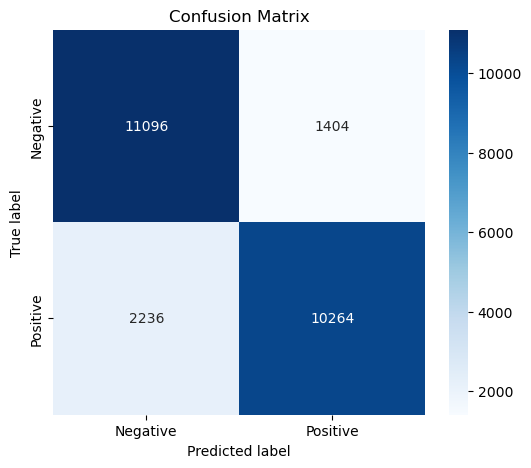


Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.89      0.86     12500
    Positive       0.88      0.82      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.86      0.85      0.85     25000
weighted avg       0.86      0.85      0.85     25000



[codecarbon INFO @ 21:58:55] Energy consumed for RAM : 0.007871 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:58:55] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:58:55] Energy consumed for All CPU : 0.033477 kWh
[codecarbon INFO @ 21:58:55] 0.041348 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 21:59:10] Energy consumed for RAM : 0.007913 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:59:10] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:59:10] Energy consumed for All CPU : 0.033654 kWh
[codecarbon INFO @ 21:59:10] 0.041567 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 21:59:25] Energy consumed for RAM : 0.007954 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 21:59:25] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:59:25] Energy consumed for All CPU

In [21]:
# Predict the probabilities of the positive class for the test data

y_pred_prod = model.predict(X_test_pad)

# Confusion Matrix

y_pred = (y_pred_prod > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Negative', 'Positive'],
           yticklabels=['Negative', 'Positive'])

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()

# Classification Report

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

In [22]:
# Sample review texts to test sentiment predictions
sample_texts = [
    "The movie was absolutely fantastic and thrilling!",
    "The movie was so bad and boring!",
    "The movie had great visuals but the storyline was dull and predictable",
    "The movie had great visuals. It was a wonderful movie",
    "The plot was decent but the acting was terrible",
    "Nothing special, just an average movie",
    "An absolute masterpiece! Brilliant in every aspect",
    "Awful. Just awful. I walked out after 30 minutes"
]

# Function to predict sentiment for a list of input texts

def predict_sentiment(texts, model, tokenizer, max_len=200):
    cleaned_texts = [clean_text(text) for text in texts]
    sequences = tokenizer.texts_to_sequences(cleaned_texts)
    padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
    
    predictions = model.predict(padded_sequences)
    
    for text, pred in zip(texts, predictions):
        sentiment = "Positive" if pred[0] >= 0.5 else "Negative"
        print("Review:", text)
        print("Prediction score:", round(float(pred[0]), 4))
        print("Predicted sentiment:", sentiment)
        print("-" * 60)

# Run the sentiment prediction function on the sample texts

predict_sentiment(sample_texts, model, tokenizer)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
Review: The movie was absolutely fantastic and thrilling!
Prediction score: 0.7852
Predicted sentiment: Positive
------------------------------------------------------------
Review: The movie was so bad and boring!
Prediction score: 0.1877
Predicted sentiment: Negative
------------------------------------------------------------
Review: The movie had great visuals but the storyline was dull and predictable
Prediction score: 0.4639
Predicted sentiment: Negative
------------------------------------------------------------
Review: The movie had great visuals. It was a wonderful movie
Prediction score: 0.8978
Predicted sentiment: Positive
------------------------------------------------------------
Review: The plot was decent but the acting was terrible
Prediction score: 0.189
Predicted sentiment: Negative
------------------------------------------------------------
Review: Nothing special, just an average movie
Prediction score: 0.3551
Predicted sent

[codecarbon INFO @ 22:01:25] Energy consumed for RAM : 0.008288 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:01:25] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 22:01:25] Energy consumed for All CPU : 0.035248 kWh
[codecarbon INFO @ 22:01:25] 0.043536 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 22:01:40] Energy consumed for RAM : 0.008329 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:01:40] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 22:01:40] Energy consumed for All CPU : 0.035425 kWh
[codecarbon INFO @ 22:01:40] 0.043755 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 22:01:40] 0.000057 g.CO2eq/s mean an estimation of 1.8100866980672525 kg.CO2eq/year
[codecarbon INFO @ 22:01:55] Energy consumed for RAM : 0.008371 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:01:55] Delta energy consumed for CP

7. Explainability with SHAP and LIME
   
    •	Goal: Visualize and explain individual predictions.
   
    •	Task: Use SHAP and LIME to analyze the impact of specific words on sentiment classification and interpret model behavior.


[codecarbon INFO @ 22:09:11] Energy consumed for RAM : 0.009579 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:09:11] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 22:09:11] Energy consumed for All CPU : 0.040740 kWh
[codecarbon INFO @ 22:09:11] 0.050319 kWh of electricity and 0.000000 L of water were used since the beginning.



LIME explaination for text1:
The movie was so bad and boring!


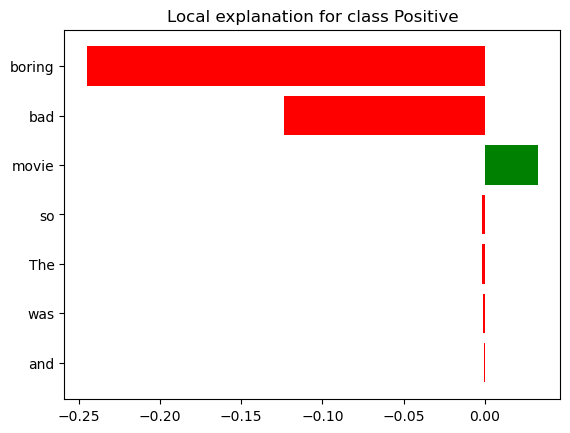

[codecarbon INFO @ 22:09:26] Energy consumed for RAM : 0.009621 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:09:26] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 22:09:26] Energy consumed for All CPU : 0.040917 kWh
[codecarbon INFO @ 22:09:26] 0.050538 kWh of electricity and 0.000000 L of water were used since the beginning.



LIME explaination for text2:
The movie had great visuals. It was a wonderful movie


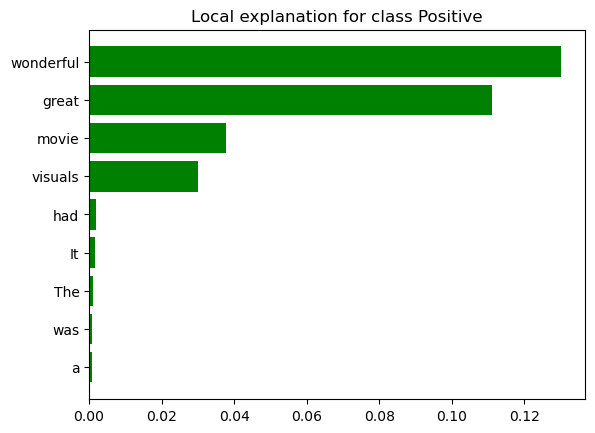


SHAP Explanation Results:


[codecarbon INFO @ 22:09:41] Energy consumed for RAM : 0.009662 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:09:41] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 22:09:41] Energy consumed for All CPU : 0.041094 kWh
[codecarbon INFO @ 22:09:41] 0.050756 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 22:09:41] 0.000057 g.CO2eq/s mean an estimation of 1.8098033772156572 kg.CO2eq/year



SHAP explanation for text 1:
The movie was so bad and boring!



SHAP explanation for text 2:
The movie had great visuals. It was a wonderful movie


[codecarbon INFO @ 22:09:56] Energy consumed for RAM : 0.009704 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:09:56] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 22:09:56] Energy consumed for All CPU : 0.041271 kWh
[codecarbon INFO @ 22:09:56] 0.050975 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 22:10:11] Energy consumed for RAM : 0.009746 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:10:11] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 22:10:11] Energy consumed for All CPU : 0.041448 kWh
[codecarbon INFO @ 22:10:11] 0.051194 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 22:10:26] Energy consumed for RAM : 0.009787 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:10:26] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 22:10:26] Energy consumed for All CPU

In [25]:
# A smaller set of sample texts for explanation analysis
sample_texts2 = [
    "The movie was so bad and boring!",
    "The movie had great visuals. It was a wonderful movie",
]

# Preprocess and pad the input text for model compatibility

cleaned_texts2 = [clean_text(text) for text in sample_texts2]
seq_texts2 = tokenizer.texts_to_sequences(cleaned_texts2)
pad_texts2 = pad_sequences(seq_texts2, maxlen=200, padding='post', truncating='post')

# ---------- LIME ----------

class_names = ['Negative', 'Positive']

def predict_proba_for_lime(texts):
    cleaned = [clean_text(text) for text in texts]
    seqs = tokenizer.texts_to_sequences(cleaned)
    pads = pad_sequences(seqs, maxlen=200, padding='post', truncating='post')
    preds = model.predict(pads, verbose=0).flatten()
    return np.column_stack([1 - preds, preds])
explainer = LimeTextExplainer(class_names=class_names)

for i, text in enumerate(sample_texts2):
    exp = explainer.explain_instance(text, predict_proba_for_lime, num_features=10)
    print(f"\nLIME explaination for text{i+1}:")
    print(text)
    fig = exp.as_pyplot_figure()
    plt.show()

# ---------- SHAP ----------

def predict_proba_for_shap(texts):
    cleaned = [clean_text(text) for text in texts]
    seqs = tokenizer.texts_to_sequences(cleaned)
    pads = pad_sequences(seqs, maxlen=200, padding='post', truncating='post')
    preds = model.predict(pads, verbose=0).flatten()
    return np.column_stack([1 - preds, preds])

print("\nSHAP Explanation Results:")

masker = shap.maskers.Text(r"\W+")
explainer_shap = shap.Explainer(predict_proba_for_shap, masker)
shap_values = explainer_shap(sample_texts2)

for i in range(len(sample_texts2)):
    print(f"\nSHAP explanation for text {i+1}:")
    print(sample_texts2[i])
    shap.plots.text(shap_values[i, :, 1])

8. Deployment Considerations
    
    •	Goal: Optimize the model for embedded or mobile environments.
    
    •	Task: Convert the model to TensorFlow Lite and compare:
    
        o	Model size
    
        o	Inference time
    
        o	Accuracy difference before/after conversion


In [33]:
# Create a TFLite converter from the trained Keras model

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

tflite_model = converter.convert()

# Save the converted model to a .tflite file

with open("sentiment_model.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model saved successfully as sentiment_model.tflite")

INFO:tensorflow:Assets written to: C:\Users\ANDRKE~1\AppData\Local\Temp\tmpckma6i52\assets


INFO:tensorflow:Assets written to: C:\Users\ANDRKE~1\AppData\Local\Temp\tmpckma6i52\assets


Saved artifact at 'C:\Users\ANDRKE~1\AppData\Local\Temp\tmpckma6i52'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200), dtype=tf.float32, name='keras_tensor_7')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2159279450704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2159279448400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2159279447248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2159279450320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2159279450512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2159279445712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2159279451088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2159279447824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2159279451664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2159279452048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  21592794

[codecarbon INFO @ 22:30:42] Energy consumed for RAM : 0.013161 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:30:42] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 22:30:42] Energy consumed for All CPU : 0.055973 kWh
[codecarbon INFO @ 22:30:42] 0.069135 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 22:30:57] Energy consumed for RAM : 0.013203 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:30:57] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 22:30:57] Energy consumed for All CPU : 0.056150 kWh
[codecarbon INFO @ 22:30:57] 0.069353 kWh of electricity and 0.000000 L of water were used since the beginning.


In [30]:
# Load the TFLite model using TensorFlow Lite Interpreter

interpreter = tf.lite.Interpreter(model_path="sentiment_model.tflite")
interpreter.allocate_tensors()


# Get input and output tensor details

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()


# Run a single inference to test functionality and measure speed

sample_input = X_test_pad[0:1].astype(input_details[0]['dtype'])

# Measure inference time for a single sample

start_time = time.time()
interpreter.set_tensor(input_details[0]['index'], sample_input)
interpreter.invoke()
end_time = time.time()

# Retrieve the output of the model

output_data = interpreter.get_tensor(output_details[0]['index'])
inference_result = output_data[0][0]
inference_time_ms = (end_time - start_time) * 1000


# Calculate the size of the .tflite model file

tflite_model_size_kb = os.path.getsize("sentiment_model.tflite") / 1024


# Run inference on the full test set using the TFLite model

y_pred_tflite = []

for i in range(len(X_test_pad)):
    input_data = X_test_pad[i:i+1].astype(input_details[0]['dtype'])
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    pred_label = 1 if output[0][0] >= 0.5 else 0
    y_pred_tflite.append(pred_label)

    
# Evaluate the TFLite model's accuracy

tflite_accuracy = accuracy_score(y_test, y_pred_tflite)

print(f"Inference result: {inference_result:.4f}")
print(f"Inference time: {inference_time_ms:.2f} ms")
print(f"TFLite model size: {tflite_model_size_kb:.2f} KB")
print(f"TFLite model accuracy: {tflite_accuracy:.4f}")


RuntimeError: Select TensorFlow op(s), included in the given model, is(are) not supported by this interpreter. Make sure you apply/link the Flex delegate before inference. For the Android, it can be resolved by adding "org.tensorflow:tensorflow-lite-select-tf-ops" dependency. See instructions: https://www.tensorflow.org/lite/guide/ops_selectNode number 1 (FlexTensorListReserve) failed to prepare.

[codecarbon INFO @ 22:22:41] Energy consumed for RAM : 0.011829 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:22:41] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 22:22:41] Energy consumed for All CPU : 0.050306 kWh
[codecarbon INFO @ 22:22:41] 0.062135 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 22:22:56] Energy consumed for RAM : 0.011870 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:22:56] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 22:22:56] Energy consumed for All CPU : 0.050483 kWh
[codecarbon INFO @ 22:22:56] 0.062353 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 22:23:11] Energy consumed for RAM : 0.011912 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 22:23:11] Delta energy consumed for CPU with constant : 0.000178 kWh, power : 42.5 W
[codecarbon INFO @ 22:23:11] Energy consumed for All CPU